# WETH/USDC Realistic Simulator

**Goal:** an end-to-end simulator of the Uniswap V3 5bp WETH/USDC pool whose retail outcomes match on-chain reality.

**Structure.** §1 and §2 show that the realistic simulator's *primitives* (price returns, retail order arrivals and sizes) match the empirical distributions where the Simple AMM Challenge defaults don't. §3 introduces the two-pool architecture. §4 calibrates the one free piece of that architecture — the V2 *normalizer pool* that represents the rest of the market — against the realized non-5bp retail impact curve. §5 validates the calibration against retail-only outcomes on the 5bp pool, which never feed into the fit. §6 reads the validation. §7 discusses how much further we should purify the retail cohort and how much residual contamination is acceptable for each downstream use.


In [1]:
import sys, os

# Add project root and presentation dir to path
_nb_dir = os.path.dirname(os.path.abspath('__file__'))
sys.path.insert(0, _nb_dir)
sys.path.insert(0, os.path.dirname(_nb_dir))

from helpers import *
%matplotlib inline

---
## Section 1: Return Distributions

The Simple AMM Challenge uses a **Geometric Brownian Motion** (GBM) model for price returns. Real ETH/USD returns (measured from Binance order book at 12-second intervals) exhibit heavier tails and regime-dependent volatility that GBM cannot capture.

Our realistic simulator uses a **5-regime Markov-switching process** fitted to empirical return quantiles.

In [2]:
observed_90d = load_binance_quantiles("90d")
challenge_rets = generate_challenge_return_quantiles()
realistic_rets = generate_realistic_return_quantiles()

### Chart 1a: Challenge (GBM) vs Observed Returns

The GBM model is too concentrated around zero — it underestimates the probability of large price moves.

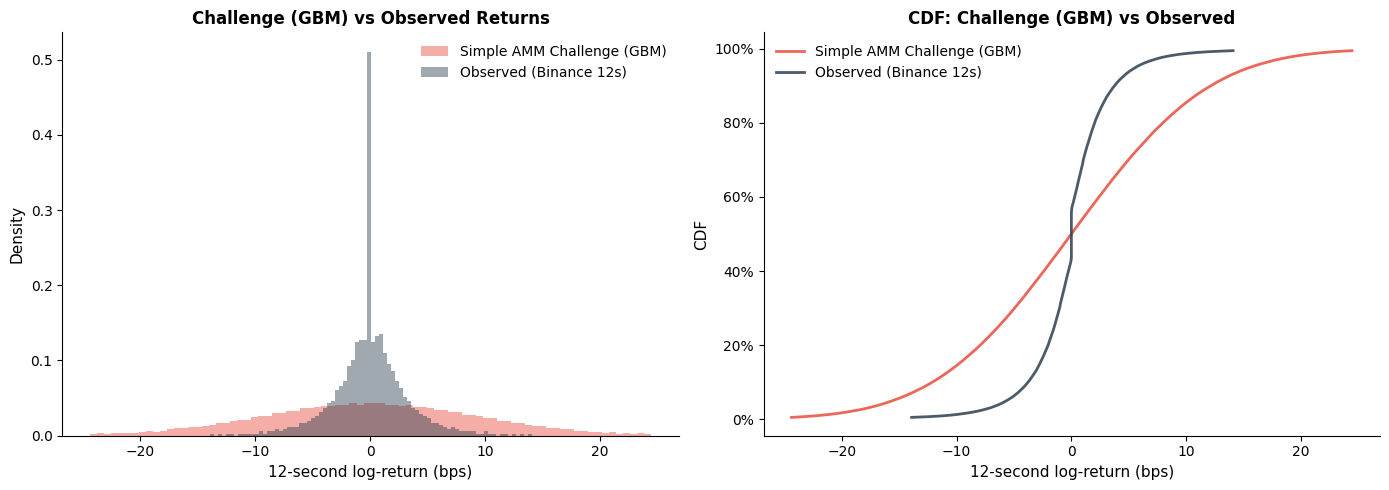

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

plot_return_hist_overlay(
    [(challenge_rets, "challenge"), (observed_90d, "observed")],
    title="Challenge (GBM) vs Observed Returns",
    ax=ax1,
)
plot_return_cdf_overlay(
    [(challenge_rets, "challenge"), (observed_90d, "observed")],
    title="CDF: Challenge (GBM) vs Observed",
    ax=ax2,
)
fig.tight_layout()
plt.show()

### Chart 1b: Realistic Simulator vs Observed Returns

The regime-switching model closely tracks the empirical distribution, including the heavy tails.

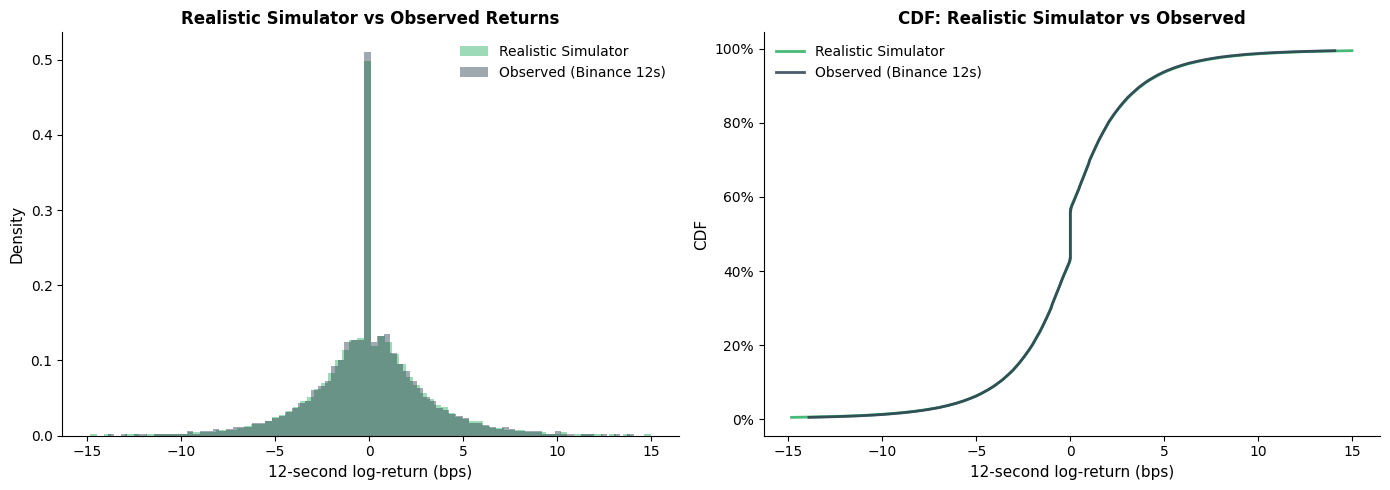

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

plot_return_hist_overlay(
    [(realistic_rets, "realistic"), (observed_90d, "observed")],
    title="Realistic Simulator vs Observed Returns",
    ax=ax1,
)
plot_return_cdf_overlay(
    [(realistic_rets, "realistic"), (observed_90d, "observed")],
    title="CDF: Realistic Simulator vs Observed",
    ax=ax2,
)
fig.tight_layout()
plt.show()

### Robustness: Consistent Across Lookback Windows

The observed distribution is stable across 90-day, 180-day, and 360-day windows.

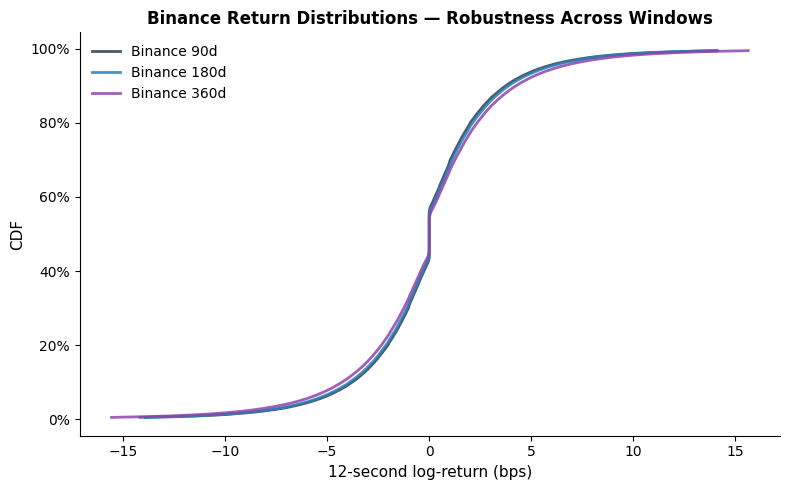

In [5]:
plot_return_robustness()
plt.tight_layout()
plt.show()

---
## Section 2: Retail Order Arrival & Size Distribution

The Challenge uses a **Poisson process** (rate=0.8/block) with **lognormal order sizes** (mean ≈ $20, σ = 1.2). Real retail flow — measured as parent-order USD sizes aggregated across **all ETH/USDC pools** using a router-address heuristic — has a very different shape.

Our realistic simulator samples **USD order sizes directly** from the empirical parent-order distribution at the observed cross-pool arrival rate (**~0.66/block**, from the cleaned 6-month cohort: 857,035 parent orders / 1,303,200 blocks).

### Chart 2a: Arrival Rates

The realistic simulator's cross-pool rate (~0.66/block) is matched to the observed 6-month rate by construction. The Challenge's fixed 0.8/block is in the same ballpark but is calibrated to nothing in particular — it lands between the 6-month (0.66) and 1–2 year (0.78–0.83) observed rates, and the per-window observed rates drift with the lookback. The single-pool rate (~0.29/block) is shown for reference — it counts only orders that touched the 5bp pool, which understates total retail flow.

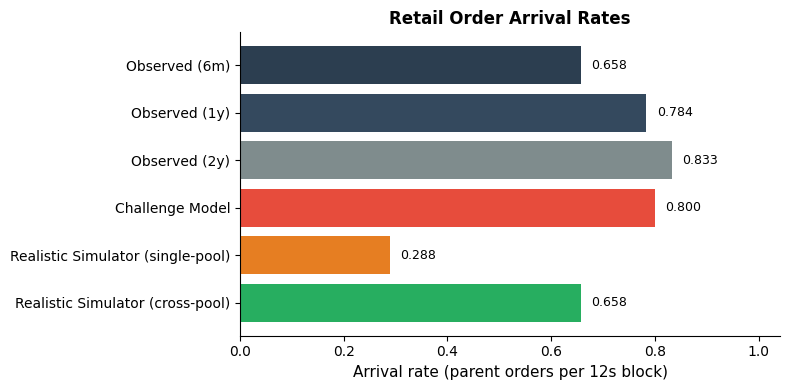

In [6]:
plot_arrival_rate_comparison()
plt.tight_layout()
plt.show()

In [7]:
observed_retail = load_parent_order_quantiles(window="6m", mode="strict", side="all")
challenge_retail = generate_challenge_retail_quantiles()
realistic_retail = generate_realistic_retail_quantiles()

### Chart 2b: Challenge (Lognormal) vs Observed Order Sizes

The lognormal model concentrates mass around $20 and completely misses the heavy right tail of real orders.

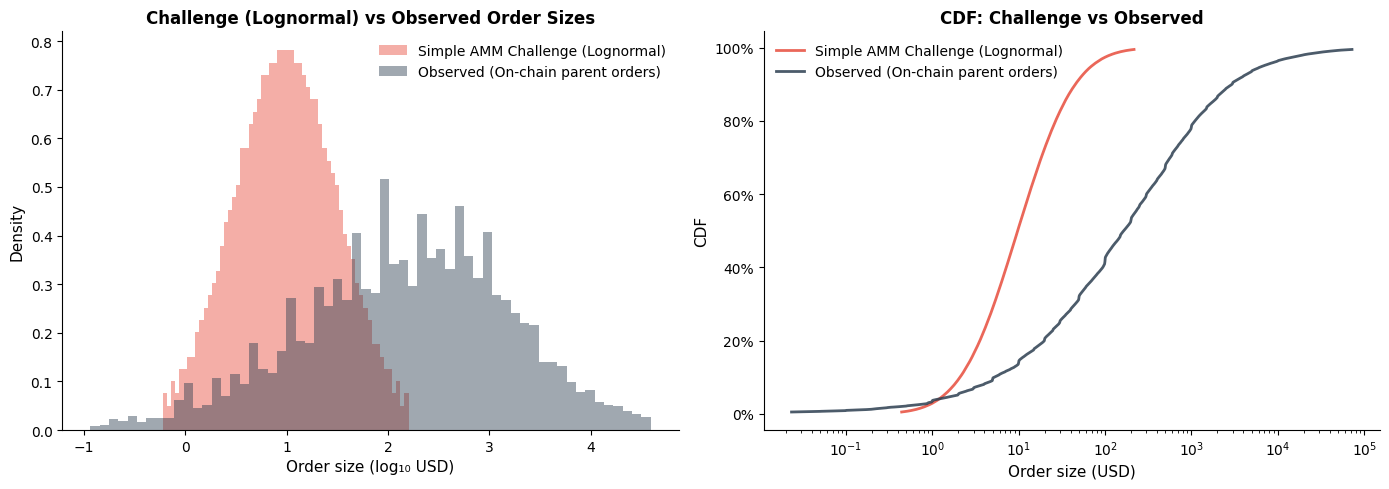

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

plot_retail_hist_overlay(
    [(challenge_retail, "challenge"), (observed_retail, "observed")],
    title="Challenge (Lognormal) vs Observed Order Sizes",
    ax=ax1,
)
plot_retail_cdf_overlay(
    [(challenge_retail, "challenge"), (observed_retail, "observed")],
    title="CDF: Challenge vs Observed",
    ax=ax2,
)
fig.tight_layout()
plt.show()

### Chart 2c: Realistic Simulator vs Observed Order Sizes

The empirical USD-size model closely matches the observed parent-order distribution.

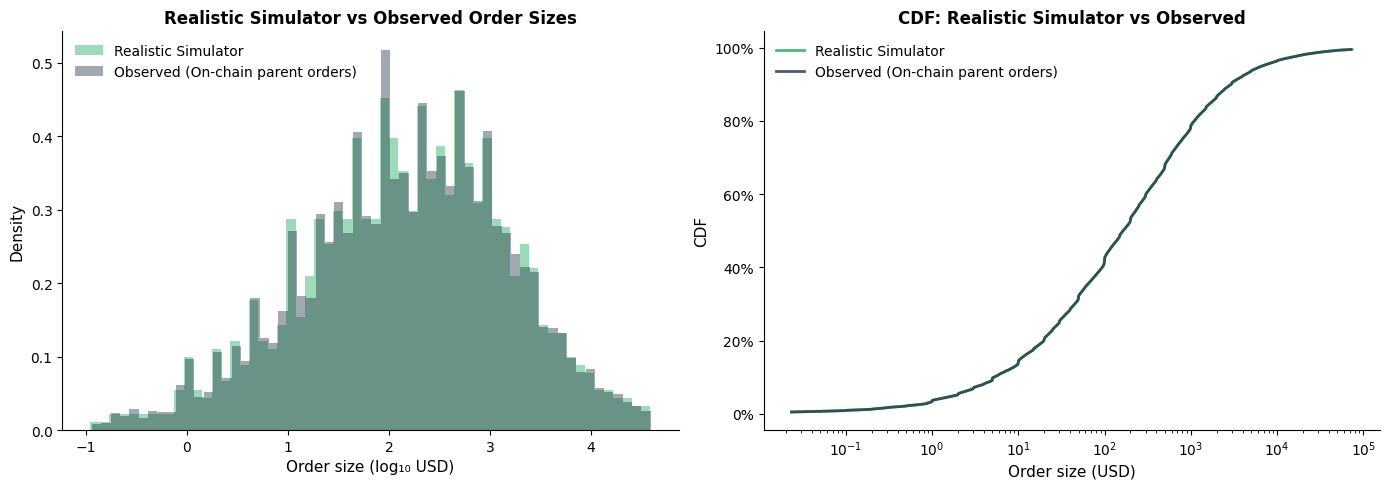

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

plot_retail_hist_overlay(
    [(realistic_retail, "realistic"), (observed_retail, "observed")],
    title="Realistic Simulator vs Observed Order Sizes",
    ax=ax1,
)
plot_retail_cdf_overlay(
    [(realistic_retail, "realistic"), (observed_retail, "observed")],
    title="CDF: Realistic Simulator vs Observed",
    ax=ax2,
)
fig.tight_layout()
plt.show()

---
## Section 3: Two-pool architecture

The simulator models the WETH/USDC market as two pools:

- **Submission pool.** The real Uniswap V3 5bp pool, **frozen** at its on-chain configuration: `fee = 5 bps`, `virtual_depth_y = $212.16M` USDC. No free parameters. Arbitrageurs trade against it each step to pull its mid toward the prevailing fair price.
- **Normalizer pool.** A single hypothetical V2 (constant-product) pool that represents *everything else* — V4 1bp + 30bp, V3 30bp, V2, Curve, Balancer, etc. Two free parameters: spread **φ** (proportional fee) and depth **D** (USDC-side).

**The normalizer is held at fair, not arbed.** At the top of every step the normalizer's mid is re-synced directly to the current fair price at constant USDC depth `D` (`reserve_y = D`, `reserve_x = D/fair`). It therefore represents the *efficient* rest-of-market — always correctly priced the instant retail arrives — and **no arbitrage ever hits it**. (Previously the normalizer was a live pool dragged toward fair by a per-step arb; that left it slightly stale between arbs and made its price depend on arb timing. Snapping it to fair removes both artifacts.) Only the 5bp submission pool is arbitraged.

Each retail order is **split across both pools to equalize their marginal execution price** (the closed-form two-AMM optimal split in `OrderRouter.split_buy/sell_two_amms`) — not routed wholesale to a single venue. The deeper / cheaper pool simply receives the larger share. The normalizer's `(φ, D)` is the only thing we calibrate.

---
## Section 4: Calibrating the normalizer pool

**Target.** The empirical price-impact curve of **strictly-retail** transactions on **non-5bp** WETH/USDC pools, referenced against the **prevailing fair price one 12s step before the trade** (the real-data analog of the simulator's "1 step before"). For each tx we measure:
- `size_usd` — total USD traded across the tx's non-5bp legs
- `spread_bps` — `1e4 × (effective_price − fair_lag) × side / fair_lag`, where `fair_lag` is the fair price at or before 12s before the trade.

**Why a strict-retail filter.** The normalizer pool exists to be a realistic *retail* competitor to the submission pool — the question it answers is how retail order routing reacts to changes in the new pool. So it should be calibrated to flow that is unambiguously human retail, not the broad router-level superset (which mixes in MM execution, arb bots, and aggregator flow). Instead of the old "19-router cohort minus markout-looking trades" heuristic, we now require an on-chain **front-end convenience-fee signature**:
- **MetaMask Swaps** — a transfer of the **87.5 bps** convenience fee to the MetaMask fee collector `0xf326e4…f1915` (Etherscan "MetaMask: DS Proxy"; empirically a clean ~87.9 bps cut). A swap that paid this fee is a human on the MetaMask front-end.
- **Uniswap interface** — *deferred*. Uniswap Labs dropped the web-interface swap fee in late 2025, so the old fee-transfer heuristic no longer isolates interface flow; the canonical on-chain signature is being confirmed before this half is added.

**Why lagged fair (not pool mid, not contemporaneous fair).** This matches the normalizer's role in §3: retail trades against a pool sitting at the prevailing fair, so we calibrate impact *relative to fair*. We use a **pre-trade** fair (one 12s step stale) so the reference cannot have been moved by the trade's own impact. The cost is noise — each trade's spread also carries ~12s of price drift — so the USD-weighted **Huber** loss (Plan B) is the robust default. The sample CSV still carries the pool-mid and contemporaneous-fair spreads as diagnostics.

**Fair-price source.** The Binance book table only covers 2023-04..2025-11, so the fair series is reconstructed from `markout_prod.benchmark` over all WETH/USDC swaps (last observation per 12s bucket, forward-filled), and each trade reads the bucket immediately preceding its own. See `analysis/weth_usdc_90d/sql/non5bp_impact_sample_v3_pool_mid_7d.sql`.

**Universe & window.** Uniswap V3 non-5bp WETH/USDC swap legs (V3 ≈ 90% of non-5bp volume), aggregated per tx, restricted to MetaMask-fee txs. The strict filter cuts the sample ~6×, so the window is widened to **30 days (2026-04-21..2026-05-20)** to keep ~3.7K transactions. One consequence to keep in mind: strictly-retail MetaMask trades are small (median ~$340, max ~$36K), so φ (the spread floor) is sharply pinned but depth **D is only weakly identified** — the impact slope is barely visible at retail sizes (the fit still prefers D≈$89M over infinite depth, but loosely). For retail-sized routing this is fine; it matters only when the sim feeds the normalizer the large trades from §2's broader size distribution.

**Model.** A V2 constant-product pool with fee φ and depth D has retail-side spread

$$\text{spread} = \frac{\varphi + (1-\varphi)\,S/D}{1-\varphi}\,.$$

**Loss.** USD-weighted Huber on residual spread (`scripts/calibration/fit_impact_curve_pool_mid.py`, Plan B; δ = 90th percentile of |residual| under the USD-weighted-L2 Plan A). We default to Plan B below.

In [10]:
fit = load_impact_curve_fit()
phi_b   = fit['plan_b']['phi']
depth_b = fit['plan_b']['depth_usdc']
print(f"Plan B fit")
print(f"  φ      = {phi_b*1e4:.3f} bps")
print(f"  depth  = ${depth_b/1e6:,.1f}M USDC")
print(f"  n_txs  = {fit['n_txs']:,}")
print(f"  window = {fit['window']}")


Plan B fit
  φ      = 1.342 bps
  depth  = $88.9M USDC
  n_txs  = 3,745
  window = 2026-04-21..2026-05-20


### Chart 3a: Empirical impact curve + V2 fit


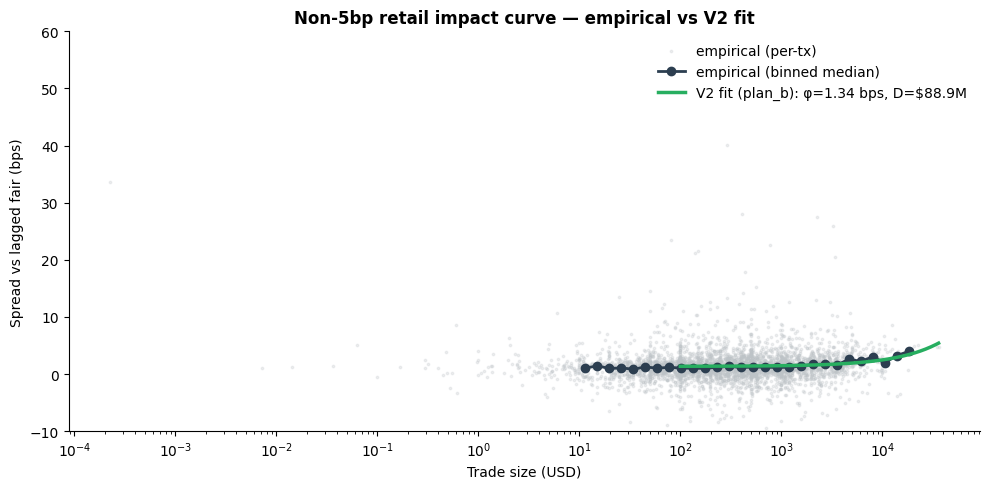

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_impact_curve_fit(ax=ax, plan_key='plan_b')
plt.tight_layout()
plt.show()


---
## Section 5: Held-out retail validation

We now run the simulator with the calibrated normalizer and the frozen 5bp submission pool, and compare three **retail-only** outcomes against on-chain reality. Crucially, none of these metrics fed into the fit — they are genuinely held out.

We focus on retail because the arb side carries no free parameters: only the 5bp submission pool is arbitraged (the normalizer is held at fair by construction, §3), and that arb is closed-form and deterministic. The retail-side metrics carry the signal about whether the normalizer pool's `(φ, D)` is correct.

**Metrics**
1. **Retail volume share at 5bp** = `retail_vol_5bp / retail_vol_total`.
2. **Retail fee share at 5bp**    = `retail_fees_5bp / retail_fees_total`.
3. **USD-weighted retail markout_15s distribution** at the 5bp pool. Convention: `markout_15s` for LP profitability (15 seconds is the standard horizon); USD-weighted percentiles emphasize the large trades that drive LP P&L.

**Real numbers** are pulled from `dex_trades` (volume + fees) and `markout_prod` (per-swap markouts) for the same window, filtered to the 19-router list. See `scripts/calibration/build_retail_share_csv.py` and `scripts/calibration/build_retail_markout_csv.py`.

**Sim numbers** are produced by `scripts/calibration/validate_pool_mid.py` with five seeds × 5,000 steps. Per-trade sim markouts use the next-block `fair_price` (~12s — closest available proxy for the 15s real reference).

In [12]:
validation = load_validation()
get_validation_summary_table()


,Metric,Real (on-chain),Simulator
0,Retail volume share @5bp,49.49%,46.63% ± 5.71pp
1,Retail fee share @5bp,17.15%,76.22% ± 3.97pp
2,Retail markout_15s — USD-w mean,+6.89 bps,+58.03 bps
3,Normalizer φ,—,1.34 bps
4,Normalizer depth,—,$88.9M
5,Submission pool fee,5.00 bps (frozen),5.00 bps (frozen)
6,Submission pool depth,$212.2M (frozen),$212.2M (frozen)


### Chart 5a: Retail volume / fee share at 5bp pool


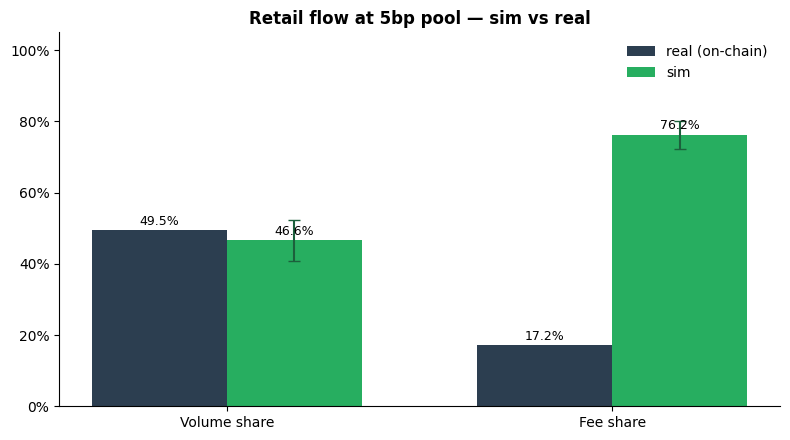

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_retail_share_bars(ax=ax)
plt.tight_layout()
plt.show()


### Chart 5b: Retail markout_15s on 5bp pool — USD-weighted


/Users/xinwan/Github/amm-gym/presentation/helpers.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10, frameon=False)


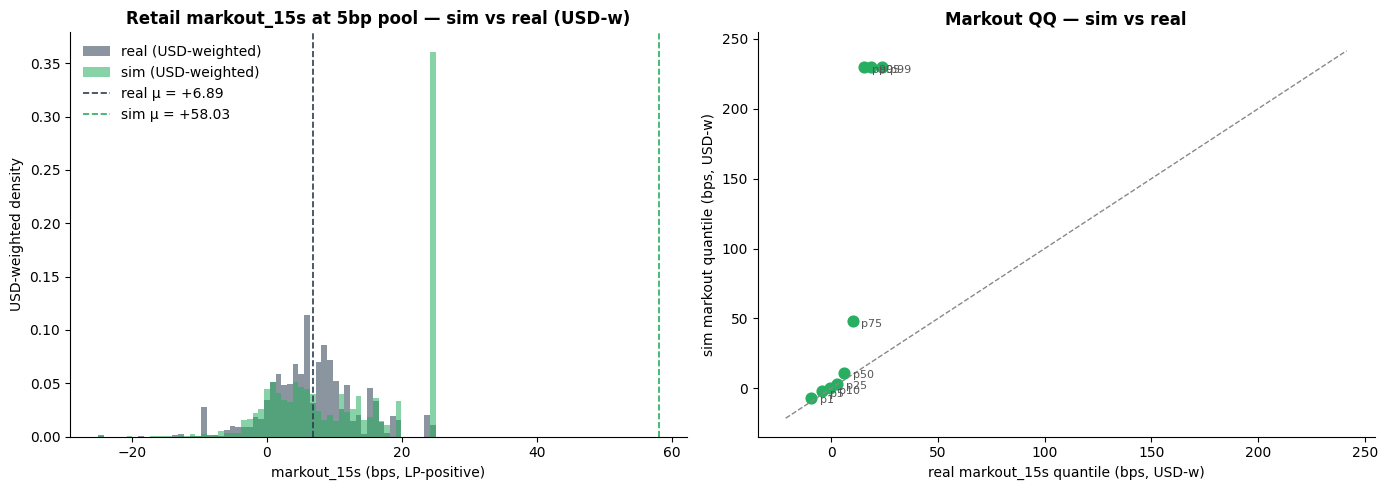

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
plot_retail_markout_overlay(ax=ax1)
plot_retail_markout_qq(ax=ax2)
plt.tight_layout()
plt.show()


---
## Section 6: Reading the validation

**Caveat on the real-world numbers.** This is the *cleaned* validation. An earlier version included two contracts (`0xbdb3…f47b6`, `0x51c7…502a7f`) in the retail-router list that turned out to be Wintermute market-maker contracts; with them in, retail volume share at the 5bp pool looked like 78%, markout looked like −3 bps, and the sim appeared to match. After removing the two MM addresses, relabeling `0x0000…1ff3` to 0x AllowanceHolder, moving CoW to a separate `intent_protocols` cohort, and adding three high-confidence aggregators, the real-side numbers below describe genuine end-user routing (see `analysis/weth_usdc_90d/router_cohorts.py`). The §2 retail size distribution and arrival rate, and the §5 real-side validation targets, are all measured on this cleaned router cohort.

**How the model is specified now (three design choices).**
1. **Normalizer held at fair, not arbed (§3).** Its mid is snapped to the current-step fair at constant USDC depth `D`; no arb touches it.
2. **Calibration referenced to lagged pre-trade fair (§4).** Impact is measured against the fair price one 12s step before each trade — the frame the normalizer sits at.
3. **Calibration sample is strictly retail (§4).** Rather than the broad 19-router cohort, only trades carrying a front-end convenience fee are used — currently **MetaMask Swaps** (87.5 bps fee to `0xf326e4…`), 3,745 non-5bp txs over a 30-day window. (The Uniswap-interface half is pending an on-chain signature for interface flow, since Uniswap dropped the web-interface fee in late 2025.) This pins the spread floor **φ = 1.34 bps**; depth **D = $88.9M** is identified but loosely, since retail trades max out around $36K and barely probe the impact slope.

**Volume share — now a close match.** Cleaned real retail routes ~49.5% of WETH/USDC flow to the 5bp pool; the simulator routes **~46.6%** (Δ −2.9 pp). This is the best volume-share fit across all revisions (pool-mid +3 pp → broad-lagged-fair +10 pp → strict-MetaMask −2.9 pp): the strict-retail fit's lower φ and deeper D make the normalizer compete more evenly for retail, instead of pushing it onto the deep 5bp pool. Volume share is volume-weighted, so it's dominated by typical-sized trades — exactly where the strict-retail calibration is most accurate.

**Fee share — still fails large.** Real retail pays only ~17% of its WETH/USDC fees at the 5bp pool; the sim produces **~76%**. A single low-φ V2 normalizer collects negligible fees and cannot match the empirical fee mix of the heterogeneous non-5bp universe. This is the binding model-misspecification; it barely moves with calibration changes.

**Markout — still tail-driven.** Cleaned real USD-weighted retail markout_15s is ~+6.9 bps; the sim shows **~+58 bps**. The residual comes almost entirely from **2 sim trades ≥ $1M** (out of 4,627 submission-pool retail trades; max ~$4.7M), produced by the *broad* §2 size distribution — which this calibration change does not touch. Real retail has zero true $1M+ trades at the 5bp pool. (Note the asymmetry this exposes: calibration now uses strictly-retail flow, but the sim still *generates* retail sizes from the broader cleaned cohort, so it feeds the loosely-identified large-`S` regime of the normalizer. Closing the markout gap needs a tail cap on §2 or retail-flow informedness in the price process — not more calibration-sample purity.)

**Takeaway.** The framework is intact and progressively cleaner: the normalizer is an idealized always-at-fair retail competitor, calibrated against a pre-trade fair on flow that is unambiguously human retail. The strict-retail filter materially improved the volume-share match — the metric that most directly reflects retail routing — which is the property the normalizer exists to get right. The two remaining gaps are structural and well-understood: (a) a single-V2 normalizer can't match the non-5bp fee mix, and (b) the markout tail is driven by the §2 size distribution and the lack of retail-flow informedness in the price process, not by the calibration sample.

---
## Section 7: On retail-dataset purity — when to keep cleaning, when to stop

Following the Wintermute discovery in §6, a natural question is: how aggressively should we keep purifying the retail dataset? The answer depends on what we're using the data for. This section walks through (a) what an additional audit of 5 random top-of-distribution transactions told us, (b) a first-principles analysis of contamination impact for each downstream use case, and (c) where to stop.

### 7.1 What further auditing revealed

We sampled 5 transactions from the top of the parent-order distribution that scored high on a contamination heuristic (top-of-block placement, multi-asset wrapper, large size) and asked an independent classifier (Pinky's data specialist) to label each from first principles — looking at call traces, sender history over 6 months, builder-coinbase tips, MEV-Inspect signals, etc. Result:

| # | Sender | Pinky's classification | Strongest evidence |
|---|---|---|---|
| 1 | `0xbe4265…0c5f` | Scheduled inventory rebalancing (large directional MM) | 6 multi-million WETH↔USDC trades over 6mo, half top-of-block, same 5-pair pattern repeats |
| 2 | `0xbe4265…0c5f` | Same as Tx 1, run 15 min later | Same fingerprint as Tx 1 |
| 3 | `0xb4d3be…186a` | Sophisticated MM cross-asset hedging — *not* atomic arb | 27 trades / $134M over 6mo across 4 aggregators incl. Curve Router |
| 4 | `0x806267…04aa` | Generalized arb bot (strongest tell) | 90% top-of-block + 100% multi-leg on *every* trade in 180 days |
| 5 | `0xef4326…80c6` | Generalized arb bot — promiscuous routing | 5 different aggregator routers used over 6mo (OpenOcean, KyberSwap, Magpie, DODO, 0x AllowanceHolder) |

All five are **non-retail**, confirming the per-tx heuristic correctly catches them. But the labels are richer than "arb": three are directional MM execution / inventory rebalancing (one-way flow), two are generalized bots, and none of the five match the atomic-arb fingerprint (zero net-token-imbalance cycle). No sandwich or backrun patterns. The single-tx heuristic also missed Tx 5 (we scored it 1; sender-history reveals it as a bot) — sender-pattern signals across time are a separate, complementary signal class.

### 7.2 First-principles: contamination impact by purpose

The simulator uses real-world retail data in three distinct ways. Each is sensitive to contamination differently.

**Purpose A — Retail size distribution (sampled per block in the sim).** The contaminating population (MMs/whales/bots) has dramatically different size statistics than retail: median multi-million-dollar trades vs retail's median ~$165. Because USD-weighted metrics like LP markout are dominated by the right tail, a small *count* of contaminating trades can move the *shape* of the tail enormously. Concretely: of the top 1000 6m parent orders, 36% score 3/3 on the contamination heuristic; filtering them would drop p100 from $7M to $1.6M (4× reduction in the extreme tail). The simulator inherits whatever tail we feed it, so a contaminated tail → too many synthetic $1M+ trades → over-stated markout and over-routing to the deep pool. **This is the most contamination-sensitive use case.**

**Purpose B — Calibration of (φ, depth) on the non-5bp impact curve.** Here we're fitting V2 mechanics to observed `(size, spread vs pre-trade fair)` pairs on real AMMs. The fit estimates the *physical* relationship between trade size and pool response — that relationship is determined by AMM math (constant-product + concentrated liquidity), not by trader identity. Whether a $100K trade comes from a retail user, a CEX-DEX arb bot, or a quant MM rebalancing inventory, the V3 1bp pool's effective spread for that size is the same. So contamination of the calibration sample is "value-equivalent" — every observation reflects the same law we're estimating. We confirmed this empirically: §4's sample had zero score≥3 contamination, and the fit residuals are dominated by the bin shape near the empirical median, not by the right tail. **This is the least contamination-sensitive use case.**

**Purpose C — Validation (comparing sim's 5bp-pool retail outcomes to real measurements).** This is about apples-to-apples comparison. If the simulator's "retail" includes some MM bots (because the size distribution it samples from is contaminated), then to validate fairly we should measure real outcomes using the same definition of "retail" — i.e., the same router-set filter. The Wintermute incident hurt us because Wintermute was inflating real-side numbers (volume share, fees) but the *simulator wasn't generating Wintermute-shaped trades*, so the comparison was apples-to-oranges. Symmetry of definition matters more here than purity per se.

### 7.3 Symmetry vs purity — the practical principle

The simulator faithfully reproduces whatever distribution we feed it. If we feed it a distribution that includes some non-retail flow, it will produce metrics that match a population including that same non-retail flow. The validation comparison is then well-posed *as long as the real-side measurements use the same population definition*. Three regimes:

- **Pure → Pure** (perfectly classified retail on both sides): cleanest interpretation, but requires a near-perfect classifier we don't have.
- **Contaminated → Contaminated, same definition**: still well-posed for comparative work. Mechanically matches, just labels the bucket "router-routed flow" rather than "retail".
- **Mismatched**: creates artificial discrepancies. This is what happened pre-cleanup.

For a simulator whose purpose is *comparative analysis* — A/B testing AMM policies, agent strategies, market-design changes — perfect purity is not required. What we need is internally consistent definitions across sim and real, and enough purity that the distribution shape isn't dominated by a few exotic outliers.

### 7.4 Recommendations per purpose

- **Size distribution (Purpose A):** marginal effort here has the highest leverage. We've already done router-set cleanup (Wintermute removal) and 10×-finer quantile resolution. The next purification step — sender-pattern filtering (eject senders showing repeat top-of-block multi-aggregator behavior over 6 months) — would drop the residual $5M+ tail trades. **Worth doing if the residual ~51 bps sim markout gap matters for your downstream use case.**
- **Calibration (Purpose B):** stop here. AMM mechanics don't care about trader identity; further filtering offers no improvement to (φ, depth) and risks shrinking the sample below useful coverage.
- **Validation (Purpose C):** keep definitions symmetric across sim and real. If you tighten the sim-side filter, tighten the real-side one identically. Mismatched definitions create the Wintermute-style artificial-discrepancy problem; that's the main thing to guard against.

### 7.5 How to be comfortable with residual contamination

Two facts argue for accepting some residual contamination:

1. **Bias is bounded and quantified.** After the router-set cleanup, removing score≥3 contamination from the markout sample shifts USD-weighted retail markout by only ~0.6 bps. For decisions framed at the scale of bps differences (policy A vs B, agent X vs Y), a 0.6 bps systematic bias cancels in the difference. We measured this directly; it's not speculative.
2. **The simulator is a comparison tool, not a forecaster.** Its absolute numbers matter less than how those numbers respond to design changes. Residual contamination that is stationary across comparisons (i.e., we don't introduce or remove bot flow as we change LP strategy) adds a constant offset that subtracts out.

Where the diminishing returns clearly bite:

- **Sender-pattern filtering risks ejecting plausibly-retail "smart router" users** whose only sin is using LI.FI/OpenOcean for best execution on a larger-than-typical trade. Past the obvious top-of-block multi-asset bots, classification ambiguity rises sharply.
- **Custom classifiers / MEV-Inspect integration** are real work to maintain and degrade as router and bot patterns evolve.

A reasonable stopping point — and where we are now — is:

- Router-set cleaned via address-level audit (Wintermute, two intent-protocol contracts moved out, three high-conf aggregators in).
- Empirical quantile resolution dense enough at the tail that no single bin spans more than ~10× in size (10000-bucket fit).
- Validation done under symmetric definitions.
- Residual gaps interpreted through the model-misspecification lens (single-V2 normalizer for the fee mix; price-process informedness for the markout tail) rather than chasing more aggressive filtering.

The remaining markout gap of ~51 bps is consistent with the simulator faithfully reproducing the distribution it's given, which still includes some directional MM/whale activity that the router heuristic can't separate from retail. If you want a tighter cohort, sender-history filtering is the next step; if you want a tighter model, the price-process and the multi-tier-normalizer ideas in §6's takeaway are higher-leverage than further router-set work.